Kamu jadi Data Analyst di "OrderKu", startup food delivery di Bangalore. Management mau tahu: siapa customer yang paling loyal, faktor apa yang bikin orang order lagi vs jarang beli, dan gimana caranya alokasi budget promo lebih tepat sasaran — bukan disebar rata ke semua customer.

In [93]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [94]:
df = pd.read_csv("../data/raw/online_food_delivery_dataset.csv")

In [95]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 388 entries, 0 to 387
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         388 non-null    int64  
 1   Gender                      388 non-null    object 
 2   Marital Status              388 non-null    object 
 3   Occupation                  388 non-null    object 
 4   Monthly Income              388 non-null    object 
 5   Educational Qualifications  388 non-null    object 
 6   Family size                 388 non-null    int64  
 7   Customer Type               388 non-null    object 
 8   latitude                    388 non-null    float64
 9   longitude                   388 non-null    float64
 10  Pin code                    388 non-null    int64  
 11  Output                      388 non-null    object 
 12  Feedback                    388 non-null    object 
 13  Unnamed: 13                 388 non

In [96]:
df.describe()

,Age,Family size,latitude,longitude,Pin code
count,388.000000,388.000000,388.000000,388.000000,388.000000
mean,24.628866,3.280928,12.972058,77.600160,560040.113402
std,2.975593,1.351025,0.044489,0.051354,31.399609
min,18.000000,1.000000,12.865200,77.484200,560001.000000
25%,23.000000,2.000000,12.936900,77.565275,560010.750000
50%,24.000000,3.000000,12.977000,77.592100,560033.500000
75%,26.000000,4.000000,12.997025,77.630900,560068.000000
max,33.000000,6.000000,13.102000,77.758200,560109.000000


In [97]:
df.isna().sum()

Age                           0
Gender                        0
Marital Status                0
Occupation                    0
Monthly Income                0
Educational Qualifications    0
Family size                   0
Customer Type                 0
latitude                      0
longitude                     0
Pin code                      0
Output                        0
Feedback                      0
Unnamed: 13                   0
dtype: int64

In [98]:
dupes = df[df.duplicated(keep=False)]
dupes.sort_values(by=list(df.columns))

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,Customer Type,latitude,longitude,Pin code,Output,Feedback,Unnamed: 13
205,20,Male,Single,Student,No Income,Graduate,2,Regular,12.9261,77.6221,560034,Yes,Positive,Yes
332,20,Male,Single,Student,No Income,Graduate,2,Regular,12.9261,77.6221,560034,Yes,Positive,Yes
348,20,Male,Single,Student,No Income,Graduate,2,Regular,12.9261,77.6221,560034,Yes,Positive,Yes
226,21,Female,Single,Student,No Income,Post Graduate,3,Regular,12.9149,77.5635,560070,Yes,Positive,Yes
313,21,Female,Single,Student,No Income,Post Graduate,3,Regular,12.9149,77.5635,560070,Yes,Positive,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
358,32,Male,Married,Employee,25001 to 50000,Graduate,3,Regular,12.9706,77.6529,560075,Yes,Positive,Yes
223,32,Male,Married,Employee,More than 50000,Graduate,5,Frequent,12.9037,77.5376,560061,Yes,Positive,Yes
310,32,Male,Married,Employee,More than 50000,Graduate,5,Frequent,12.9037,77.5376,560061,Yes,Positive,Yes
240,32,Male,Married,Employee,More than 50000,Post Graduate,6,Frequent,12.9369,77.6407,560095,Yes,Positive,Yes


In [99]:
print(df['Family size'].unique())
print(df['Family size'].dtype)

[4 3 6 2 5 1]
int64


In [100]:
df=df.drop(columns='Unnamed: 13')
df.head()

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,Customer Type,latitude,longitude,Pin code,Output,Feedback
0,20,Female,Single,Student,No Income,Post Graduate,4,Frequent,12.9766,77.5993,560001,Yes,Positive
1,24,Female,Single,Student,Below Rs.10000,Graduate,3,Regular,12.9770,77.5773,560009,Yes,Positive
2,22,Male,Single,Student,Below Rs.10000,Post Graduate,3,Regular,12.9551,77.6593,560017,Yes,Negative
3,22,Female,Single,Student,No Income,Graduate,6,Frequent,12.9473,77.5616,560019,Yes,Positive
4,22,Male,Single,Student,Below Rs.10000,Post Graduate,4,Frequent,12.9850,77.5533,560010,Yes,Positive


In [101]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

for col in categorical_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False))    # dropna=False agar NaN ikut terhitung
    print()

# Ringkas jumlah nilai unik per kolom kategorikal
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values")


--- Gender ---
Gender
Male      222
Female    166
Name: count, dtype: int64

--- Marital Status ---
Marital Status
Single               268
Married              108
Prefer not to say     12
Name: count, dtype: int64

--- Occupation ---
Occupation
Student           207
Employee          118
Self Employeed     54
House wife          9
Name: count, dtype: int64

--- Monthly Income ---
Monthly Income
No Income          187
25001 to 50000      69
More than 50000     62
10001 to 25000      45
Below Rs.10000      25
Name: count, dtype: int64

--- Educational Qualifications ---
Educational Qualifications
Graduate         177
Post Graduate    174
Ph.D              23
School            12
Uneducated         2
Name: count, dtype: int64

--- Customer Type ---
Customer Type
Regular     218
Frequent    146
New          24
Name: count, dtype: int64

--- Output ---
Output
Yes    301
No      87
Name: count, dtype: int64

--- Feedback ---
Feedback
Positive     317
Negative      71
Name: count, dtype: in

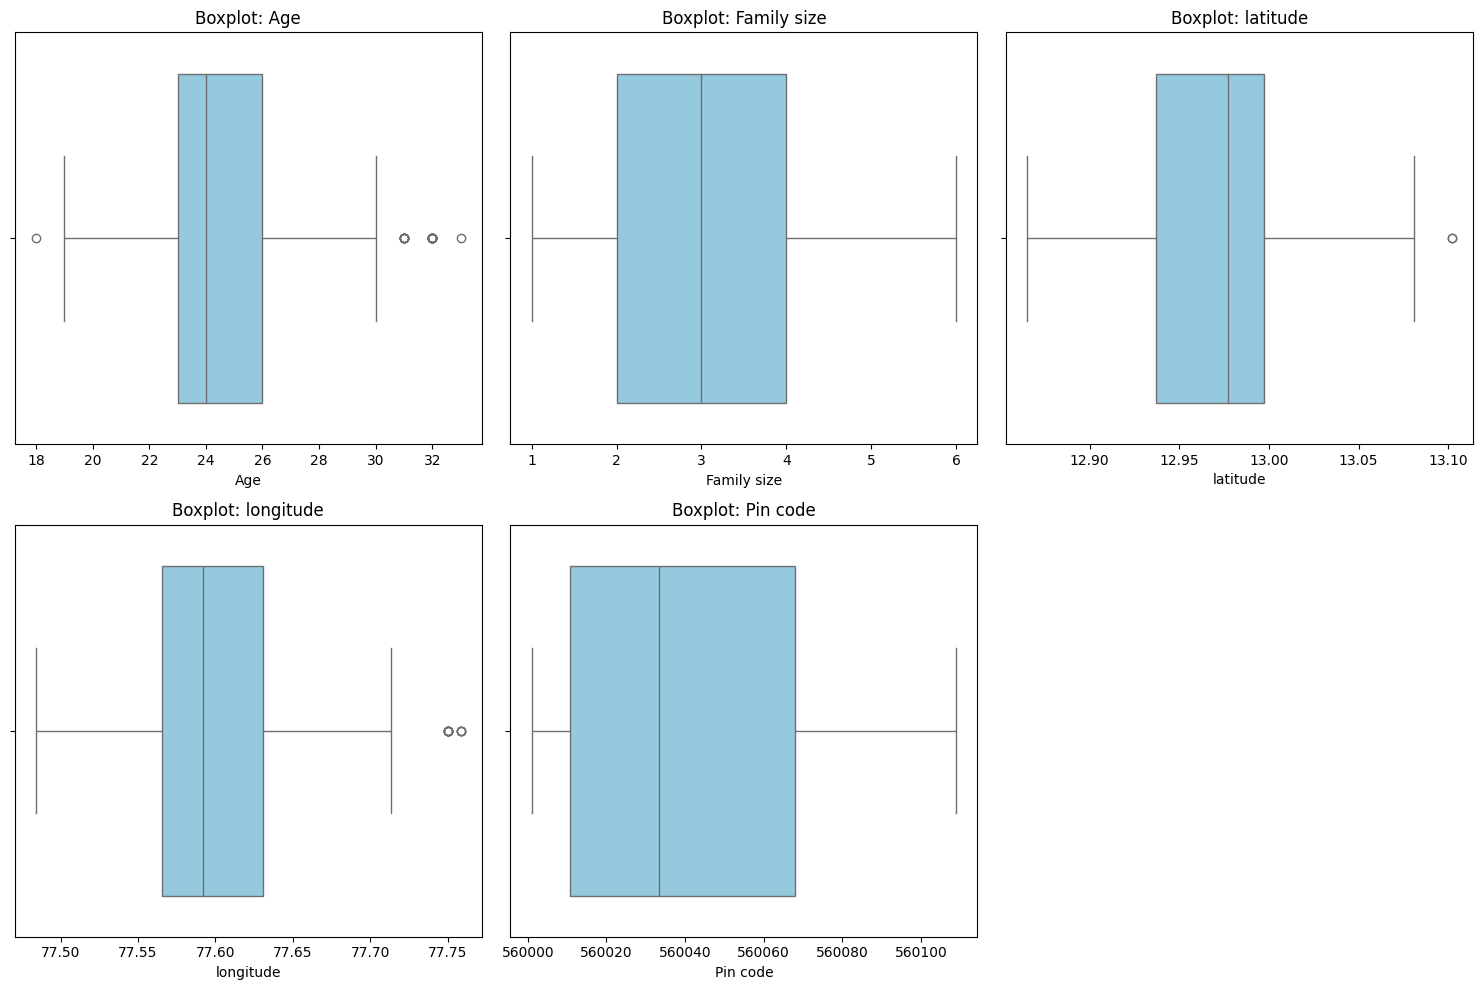

In [102]:
import math
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
n_rows = math.ceil(len(numerical_cols) / 3)

plt.figure(figsize=(15, 5 * n_rows))
for i, col in enumerate(numerical_cols):
    plt.subplot(n_rows, 3, i + 1)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Boxplot: {col}')
plt.tight_layout()
plt.show()


In [103]:
pd.crosstab(df['Customer Type'], df['Output'])

Output,No,Yes
Customer Type,,
Frequent,34,112
New,7,17
Regular,46,172


In [104]:
df['Segment'] = df['Customer Type'].astype(str) + ' - ' + df['Output'].astype(str)

In [105]:
segment_sizes = df['Segment'].value_counts()
print(segment_sizes)

Segment
Regular - Yes     172
Frequent - Yes    112
Regular - No       46
Frequent - No      34
New - Yes          17
New - No            7
Name: count, dtype: int64


In [106]:
def profile_by_segment(df, column, segment_col='Segment'):
    """
    Tampilkan distribusi persentase satu kolom kategorikal, dipecah per segmen.
    """
    ct = pd.crosstab(df[segment_col], df[column], normalize='index') * 100
    return ct.round(1)

kolom_profil = ['Age','Occupation', 'Monthly Income', 'Marital Status', 
                 'Feedback', 'Educational Qualifications', 'Gender']

for col in kolom_profil:
    print(f"\n=== Profil Segmen berdasarkan: {col} ===")
    print(profile_by_segment(df, col))


=== Profil Segmen berdasarkan: Age ===
Age              18   19   20    21    22    23    24    25    26    27   28  \
Segment                                                                        
Frequent - No   0.0  0.0  0.0   0.0   0.0   0.0   5.9  11.8  20.6  26.5  5.9   
Frequent - Yes  0.9  2.7  0.9   6.2  22.3  22.3  12.5   7.1   4.5   0.0  1.8   
New - No        0.0  0.0  0.0   0.0   0.0   0.0   0.0  14.3  14.3   0.0  0.0   
New - Yes       0.0  0.0  0.0  11.8  17.6  29.4   0.0  23.5   5.9   5.9  5.9   
Regular - No    0.0  2.2  2.2  10.9   4.3  17.4  17.4   8.7  17.4   2.2  6.5   
Regular - Yes   0.0  0.0  4.1   5.2  15.7  20.3  15.1  18.0   7.6   5.8  4.1   

Age               29    30    31    32   33  
Segment                                      
Frequent - No   17.6   8.8   0.0   0.0  2.9  
Frequent - Yes   2.7   3.6   4.5   8.0  0.0  
New - No         0.0  28.6  28.6  14.3  0.0  
New - Yes        0.0   0.0   0.0   0.0  0.0  
Regular - No     8.7   0.0   0.0   2.2  0.0

In [107]:
segmen_fokus = ['Frequent - Yes', 'Frequent - No']  # Loyal Kuat vs Loyal Rawan Churn

subset = df[df['Segment'].isin(segmen_fokus)]

for col in kolom_profil:
    print(f"\n=== {col}: Loyal Kuat vs Loyal Rawan Churn ===")
    print(profile_by_segment(subset, col))


=== Age: Loyal Kuat vs Loyal Rawan Churn ===
Age              18   19   20   21    22    23    24    25    26    27   28  \
Segment                                                                       
Frequent - No   0.0  0.0  0.0  0.0   0.0   0.0   5.9  11.8  20.6  26.5  5.9   
Frequent - Yes  0.9  2.7  0.9  6.2  22.3  22.3  12.5   7.1   4.5   0.0  1.8   

Age               29   30   31   32   33  
Segment                                   
Frequent - No   17.6  8.8  0.0  0.0  2.9  
Frequent - Yes   2.7  3.6  4.5  8.0  0.0  

=== Occupation: Loyal Kuat vs Loyal Rawan Churn ===
Occupation      Employee  House wife  Self Employeed  Student
Segment                                                      
Frequent - No       55.9         2.9            29.4     11.8
Frequent - Yes      25.9         5.4             8.0     60.7

=== Monthly Income: Loyal Kuat vs Loyal Rawan Churn ===
Monthly Income  10001 to 25000  25001 to 50000  Below Rs.10000  \
Segment                                  

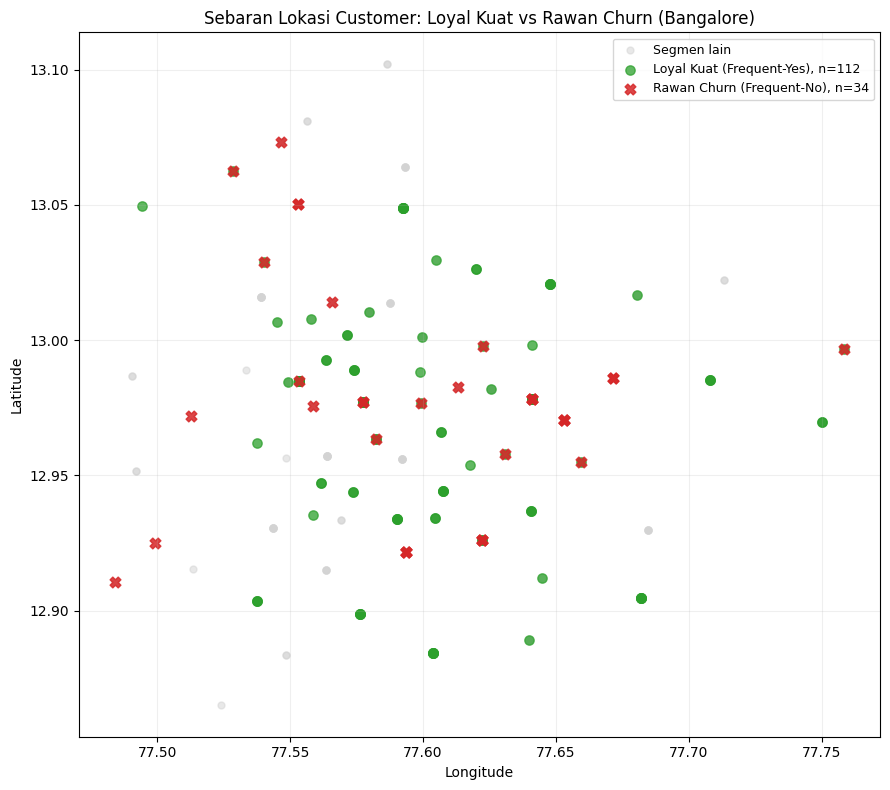

In [108]:
others = df[~df['Segment'].isin(['Frequent - Yes', 'Frequent - No'])]
loyal = df[df['Segment'] == 'Frequent - Yes']   # Loyal Kuat
churn = df[df['Segment'] == 'Frequent - No']    # Rawan Churn

fig, ax = plt.subplots(figsize=(9, 8))

ax.scatter(others['longitude'], others['latitude'], 
           c='lightgray', s=25, alpha=0.5, label='Segmen lain')

# plot Loyal Kuat (hijau, bulat)
ax.scatter(loyal['longitude'], loyal['latitude'], 
           c='#2ca02c', s=45, alpha=0.75, 
           label=f'Loyal Kuat (Frequent-Yes), n={len(loyal)}')

# plot Rawan Churn (merah, marker X biar beda bentuk selain warna)
ax.scatter(churn['longitude'], churn['latitude'], 
           c='#d62728', s=60, alpha=0.85, marker='X', 
           label=f'Rawan Churn (Frequent-No), n={len(churn)}')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Sebaran Lokasi Customer: Loyal Kuat vs Rawan Churn (Bangalore)')
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# Insight Analisis Customer OrderKu

## Metodologi singkat
Loyalitas didefinisikan dari kombinasi dua sinyal: `Customer Type` (persepsi diri responden) dan `Output` (niat order lagi). Kombinasi ini menghasilkan 6 segmen, dengan dua yang paling krusial untuk bisnis:
- **Loyal Kuat** (Frequent–Yes, n=112): sudah sering order dan berniat lanjut
- **Rawan Churn** (Frequent–No, n=34): sudah sering order tapi berniat berhenti — ini target retensi paling berharga karena histori loyalitasnya sudah terbukti

Faktor dianalisis pakai Chi-square + Cramér's V (effect size). `Family size` dikeluarkan dari kesimpulan karena terbukti deterministik terhadap `Customer Type` (data leakage), bukan sinyal independen.

---

## 1. Siapa customer paling loyal?

**Profil Loyal Kuat (Frequent–Yes):**
- Usia muda, median **23 tahun** (rentang kuartil 22–25), jelas lebih muda dibanding Rawan Churn (median 27 tahun, rentang 26–29)
- Mayoritas **Student** (60.7%, vs 11.8% di Rawan Churn)
- **Single** (72.3%, vs 17.6% di Rawan Churn)
- **No Income** atau berpenghasilan rendah (58.0% No Income, vs 14.7% di Rawan Churn)
- **Feedback Positive** dominan (96.4%)

**Kenapa mereka loyal:** kombinasi usia muda, belum menikah, dan belum punya kewajiban finansial besar (student, belum berpenghasilan tetap) membuat pola konsumsi mereka lebih aktif dan repetitif — order jadi bagian dari gaya hidup harian, bukan keputusan yang dipertimbangkan berat.

## 2. Siapa yang paling jarang order / rawan churn?

**Profil Rawan Churn (Frequent–No):** sudah terbukti sering order di masa lalu, tapi:
- Usia lebih tua, median **27 tahun**
- Mayoritas **Married** (79.4%, vs 25.9% di Loyal Kuat)
- Bekerja — **Employee** (55.9%) atau **Self Employed** (29.4%)
- **Feedback Negative** dominan (64.7%, vs 3.6% di Loyal Kuat) — gap ini yang terbesar dari semua faktor

Lokasi (latitude/longitude/Pin code) **tidak menunjukkan pola geografis yang jelas** — pelanggan loyal dan rawan churn tersebar merata di seluruh area Bangalore. Artinya strategi retensi sebaiknya berbasis **karakteristik pelanggan**, bukan wilayah.

## 3. Peluang retensi terbesar: bukan cuma Frequent–No

Selain Frequent–No (34 orang), segmen **Regular–No (46 orang)** justru punya volume lebih besar dan potensi serupa: mereka sudah pernah order dengan pola yang cukup konsisten (Regular), tapi berniat berhenti. Total **80 pelanggan** di dua segmen "No" ini adalah basis retensi paling konkret — mereka bukan prospek baru yang belum tentu convert, tapi pelanggan existing yang sedang berada di titik keputusan untuk pergi.

---

## Rekomendasi alokasi budget promo

| Prioritas | Target | Ukuran | Strategi | Dasar |
|---|---|---|---|---|
| 1 | Semua customer dengan Feedback Negative | 71 | Service recovery: follow-up personal + voucher kompensasi | Gap churn 64, faktor terkuat |
| 2 | Regular – No | 46 | Reactivation: promo "2x order" atau free delivery | Volume terbesar di kelompok at-risk |
| 3 | Frequent – No | 34 | Win-back: cek keluhan spesifik + insentif kembali | Histori loyalitas tinggi, sunk cost akuisisi sudah ada |
| 4 | Loyal Kuat (Frequent–Yes) | 112 | Loyalty reward / member voucher — pertahankan, jangan diabaikan | Basis revenue utama saat ini |
| 5 | New – Yes | 17 | Nurturing: dorong ke Regular/Frequent | Onboarding awal |

**Prinsip utama:** budget promo tidak perlu disebar rata. Kelompok dengan feedback negatif dan status "No" (baik Regular maupun Frequent) adalah target dengan urgensi dan potensi ROI tertinggi, karena mereka pelanggan existing yang tinggal satu dorongan lagi untuk bertahan atau pergi.

---

## Keterbatasan yang perlu disampaikan ke management
- Beberapa segmen kombinasi (terutama New–No, n=7) terlalu kecil untuk disimpulkan dengan yakin

In [110]:
def age_bucket(age):
    if age <= 21:
        return '18-21'
    elif age <= 25:
        return '22-25'
    elif age <= 29:
        return '26-29'
    else:
        return '30-33'

df['Age Bucket'] = df['Age'].apply(age_bucket)

In [111]:
df.to_csv("../data/processed/orderku_cleaned.csv", index=False)